# Forman Profile: learned sheaf curvature vs topological reference

## 1. Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, wasserstein_distance

## 2. Config

In [2]:
dataset         = "roman_empire"  # "cora", "citeseer", "pubmed", "cornell", "wisconsin", "roman_empire", "amazon_ratings", "questions", "tolokers"
model           = "JointSheafParams"  # "GeneralSheaf", "JointSheafParams", "JointSheafParamsAlt"
Norm            = "false"          # "true" or "false"
stalk_dim       = 5
layers          = 5
hidden_channels = 16
epochs          = 500
seed            = 43
num_folds       = 10

NUM_NODES = {
    "roman_empire":   22662,
    "minesweeper":    10000,
    "cora":           2708,
    "citeseer":       3327,
    "pubmed":         19717,
    "cornell":        183,
    "wisconsin":      251,
    "amazon_ratings": 24492,
    "questions":      48921,
    "tolokers":       11758,
}
num_nodes = NUM_NODES[dataset]
n, d = num_nodes, stalk_dim

# map_type choices: 'identity', 'diag', 'bundle', 'general'  (only used for Joint models)
_JOINT_MODELS = {'JointSheafParams', 'JointSheafParamsAlt'}
map_type = 'general'
map_tag  = f"_first_maps_{map_type}" if model in _JOINT_MODELS else ""

BASE = (f"../results/forman_eigs/{dataset}/{model}{map_tag}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
        f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs")

def eigs_path(layer, fold):
    return os.path.join(BASE, f"{model}_{dataset}_layer{layer}_fold{fold}{map_tag}_seed{seed}.npy")

def f0_top_path(fold):
    return os.path.join(BASE, f"f0_top_{dataset}_n{n}_fold{fold}_seed{seed}.npy")

print(f"dataset={dataset}  model={model}  norm={Norm}  d={d}  layers={layers}")
print(f"map_tag={map_tag!r}")
print(f"BASE={BASE}")

dataset=roman_empire  model=JointSheafParams  norm=false  d=5  layers=5
map_tag='_first_maps_general'
BASE=../results/forman_eigs/roman_empire/JointSheafParams_first_maps_general/normalised-false/stalk_dim-5/5-layers/16-hidden/500-epochs


## 3. Topological reference

`f0_top` is pre-computed during training and saved as `.npy` alongside the eigenvalues — load it directly.

In [3]:
f0_top = np.load(f0_top_path(fold=0))
print(f"f0_top loaded: n={len(f0_top)}, range=[{f0_top.min():.3f}, {f0_top.max():.3f}]")

f0_top loaded: n=22662, range=[-0.826, 0.259]


## 4. Forman curvature across all folds

`all_curv_eigs[fold, layer, node, k]` is the k-th eigenvalue of the Forman block F_{u,u},
loaded from the pre-computed `.npy` files saved during training.

In [4]:
all_curv_eigs = np.zeros((num_folds, layers, n, d))

for fold in range(num_folds):
    for layer in range(layers):
        path = eigs_path(layer, fold)
        if not os.path.exists(path):
            print(f"  WARNING: missing fold={fold} layer={layer} — {path}")
            continue
        all_curv_eigs[fold, layer] = np.load(path)
    print(f"fold {fold} done")

mean_curv = all_curv_eigs.mean(axis=0)   # (layers, n, d)
std_curv  = all_curv_eigs.std(axis=0)    # (layers, n, d)

fold 0 done
fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done
fold 6 done
fold 7 done
fold 8 done
fold 9 done


## 6. Mean Forman Profile

Each subplot shows the mean curvature eigenvalue (averaged over folds) vs the topological scalar curvature f0,
with a ±1 std band. Nodes are sorted by f0_top on the x-axis.
The Spearman ρ is computed on the mean profile.

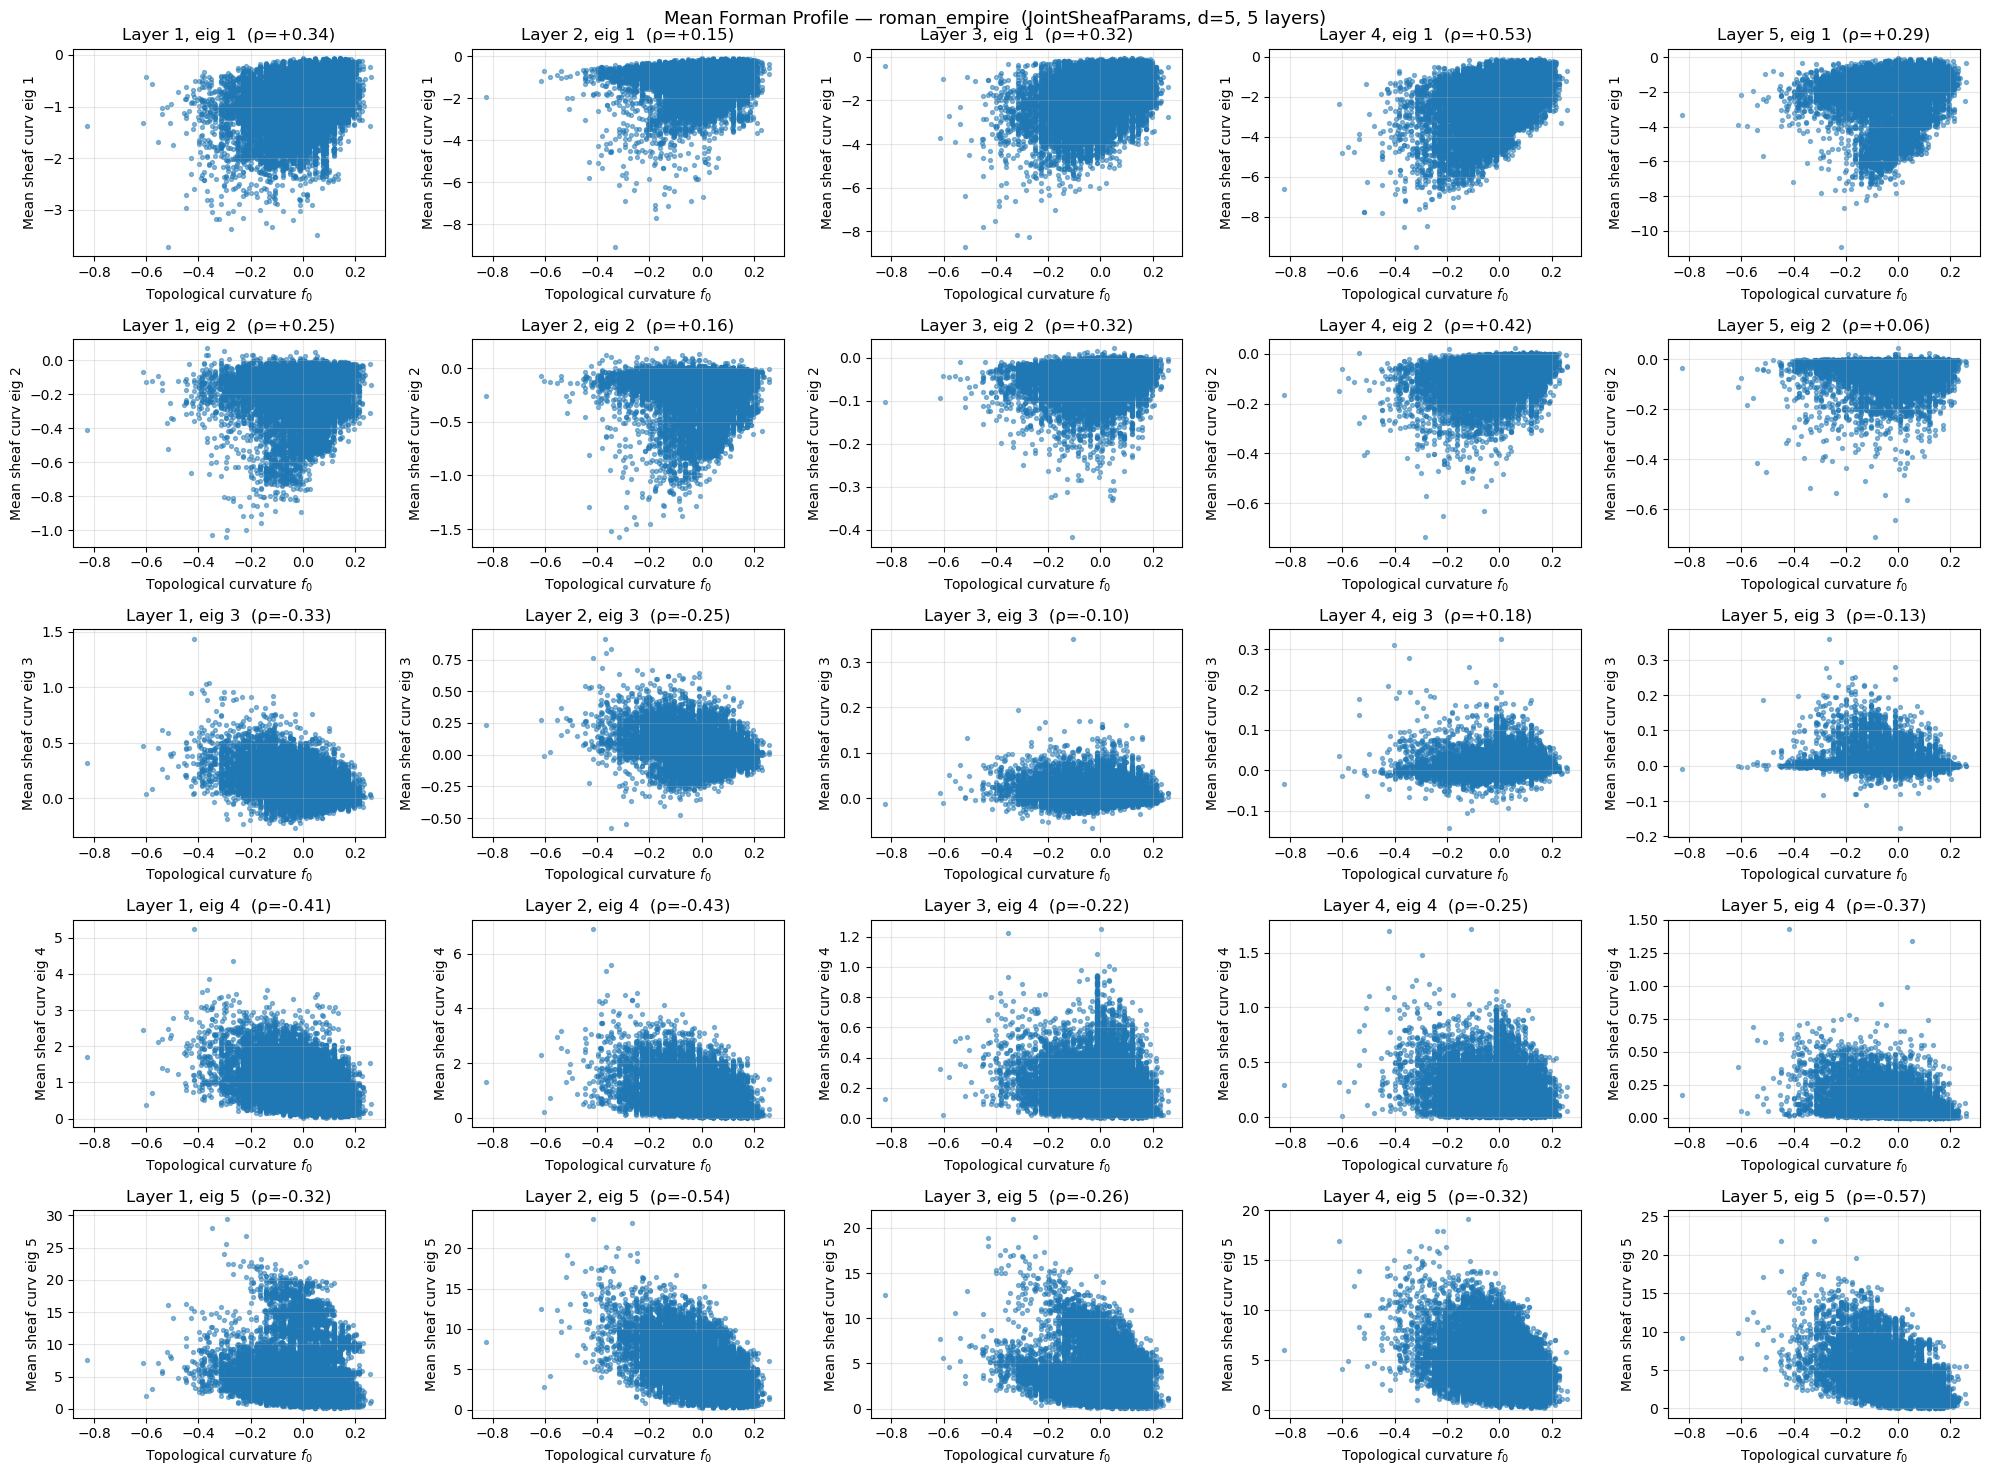

In [5]:
fig, axes = plt.subplots(d, layers, figsize=(4 * layers, 3 * d))
if layers == 1:
    axes = axes.reshape(-1, 1)

for k in range(d):
    for layer in range(layers):
        ax  = axes[k, layer]
        mu  = mean_curv[layer, :, k]
        rho = spearmanr(mu, f0_top).statistic

        ax.scatter(f0_top, mu, s=8, alpha=0.5)
        ax.set_title(f"Layer {layer+1}, eig {k+1}  (ρ={rho:+.2f})")
        ax.set_xlabel("Topological curvature $f_0$")
        ax.set_ylabel(f"Mean sheaf curv eig {k+1}")
        ax.grid(alpha=0.3)

fig.suptitle(f"Mean Forman Profile — {dataset}  ({model}, d={d}, {layers} layers)", fontsize=13)
fig.tight_layout()
#plt.savefig(f"../figures/{dataset}_{model}_d{d}_forman_profile.pdf", bbox_inches="tight")
plt.show()


## 7. Numerical metrics

For each fold we compute three alignment scores between each curvature eigenvalue channel and f0_top,
then report mean ± std across the 10 folds.

- **Spearman ρ**: rank correlation — scale-free, directly measures node-level alignment.
- **Pearson r**: linear correlation — catches how well the linear trend holds.
- **Wasserstein**: distance between the two normalized distributions — measures shape similarity independent of node ordering.
- **L2 distance**

In [7]:
f0_norm = (f0_top - f0_top.mean()) / f0_top.std()

spearman_vals    = np.zeros((num_folds, layers, d))
spearman_pvals   = np.zeros((num_folds, layers, d))
pearson_vals     = np.zeros((num_folds, layers, d))
pearson_pvals    = np.zeros((num_folds, layers, d))
wasserstein_vals = np.zeros((num_folds, layers, d))
rmse_vals        = np.zeros((num_folds, layers, d))
nrmse_vals       = np.zeros((num_folds, layers, d))
scale_ratio_vals = np.zeros((num_folds, layers, d))

for fold in range(num_folds):
    for layer in range(layers):
        for k in range(d):
            c      = all_curv_eigs[fold, layer, :, k]
            c_norm = (c - c.mean()) / (c.std() + 1e-9)

            spr = spearmanr(c, f0_top)
            pe  = pearsonr(c, f0_top)

            spearman_vals[fold, layer, k]    = spr.statistic
            spearman_pvals[fold, layer, k]   = spr.pvalue
            pearson_vals[fold, layer, k]     = pe.statistic
            pearson_pvals[fold, layer, k]    = pe.pvalue
            wasserstein_vals[fold, layer, k] = wasserstein_distance(c_norm, f0_norm)
            rmse_vals[fold, layer, k]        = np.sqrt(np.mean((c - f0_top) ** 2))
            nrmse_vals[fold, layer, k]       = np.sqrt(np.mean((c_norm - f0_norm) ** 2))
            scale_ratio_vals[fold, layer, k] = c.std() / (f0_top.std() + 1e-9)

def fold_stats(arr):
    return arr.mean(axis=0), arr.std(axis=0)

spearman_mean,    spearman_std    = fold_stats(spearman_vals)
pearson_mean,     pearson_std     = fold_stats(pearson_vals)
wasserstein_mean, wasserstein_std = fold_stats(wasserstein_vals)
rmse_mean,        rmse_std        = fold_stats(rmse_vals)
nrmse_mean,       nrmse_std       = fold_stats(nrmse_vals)
scale_ratio_mean, scale_ratio_std = fold_stats(scale_ratio_vals)

# plot style — defined once, shared by both plot cells
PALETTE = [
    "#E6A817",   # gold
    "#4169E1",   # royal blue
    "#E8735A",   # salmon
    "#5BAD6F",   # sage green
    "#9B72B0",   # soft purple
    "#5BB8C9",   # steel blue
    "#C97D4E",   # terracotta
    "#C75B8A",   # rose
]
colors      = PALETTE[:d]
layer_ticks = np.arange(1, layers + 1)

### Table

In [8]:
hdr1 = f"{'Layer':>6}  {'Eig':>4}  {'Spearman':>18}  {'Pearson':>18}  {'Wasserstein':>18}"
print(hdr1)
print("-" * len(hdr1))
for layer in range(layers):
    for k in range(d):
        print(f"{layer+1:>6}  {k+1:>4}  "
              f"{spearman_mean[layer,k]:+.3f} \u00b1 {spearman_std[layer,k]:.3f}  "
              f"{pearson_mean[layer,k]:+.3f} \u00b1 {pearson_std[layer,k]:.3f}  "
              f"{wasserstein_mean[layer,k]:.3f} \u00b1 {wasserstein_std[layer,k]:.3f}")

print()


 Layer   Eig            Spearman             Pearson         Wasserstein
------------------------------------------------------------------------
     1     1  +0.816 ± 0.030  +0.847 ± 0.022  0.418 ± 0.017
     1     2  +0.791 ± 0.041  +0.721 ± 0.103  0.501 ± 0.048
     1     3  +0.795 ± 0.074  +0.595 ± 0.097  0.497 ± 0.069
     1     4  +0.898 ± 0.077  +0.586 ± 0.094  0.519 ± 0.029
     1     5  +0.950 ± 0.015  +0.699 ± 0.025  0.473 ± 0.008
     2     1  +0.791 ± 0.046  +0.867 ± 0.020  0.367 ± 0.010
     2     2  +0.807 ± 0.048  +0.779 ± 0.079  0.427 ± 0.033
     2     3  +0.798 ± 0.071  +0.707 ± 0.087  0.381 ± 0.086
     2     4  +0.836 ± 0.121  +0.675 ± 0.100  0.440 ± 0.028
     2     5  +0.863 ± 0.071  +0.671 ± 0.078  0.432 ± 0.024
     3     1  +0.788 ± 0.030  +0.852 ± 0.015  0.308 ± 0.022
     3     2  +0.801 ± 0.039  +0.838 ± 0.029  0.274 ± 0.035
     3     3  +0.778 ± 0.048  +0.818 ± 0.043  0.212 ± 0.059
     3     4  +0.740 ± 0.056  +0.729 ± 0.052  0.297 ± 0.041
     3     5  

In [9]:
hdr2 = f"{'Layer':>6}  {'Eig':>4}  {'RMSE':>18}  {'NRMSE':>18}  {'Scale ratio':>18}"
print(hdr2)
print("-" * len(hdr2))
for layer in range(layers):
    for k in range(d):
        print(f"{layer+1:>6}  {k+1:>4}  "
              f"{rmse_mean[layer,k]:.3f} ± {rmse_std[layer,k]:.3f}  "
              f"{nrmse_mean[layer,k]:.3f} ± {nrmse_std[layer,k]:.3f}  "
              f"{scale_ratio_mean[layer,k]:.3f} ± {scale_ratio_std[layer,k]:.3f}")

 Layer   Eig                RMSE               NRMSE         Scale ratio
------------------------------------------------------------------------
     1     1  0.146 ± 0.006  0.552 ± 0.038  0.582 ± 0.105
     1     2  0.175 ± 0.016  0.736 ± 0.129  0.287 ± 0.129
     1     3  0.202 ± 0.009  0.893 ± 0.116  0.053 ± 0.061
     1     4  0.190 ± 0.012  0.904 ± 0.101  0.141 ± 0.086
     1     5  0.164 ± 0.008  0.775 ± 0.031  0.372 ± 0.101
     2     1  0.147 ± 0.006  0.515 ± 0.037  0.839 ± 0.048
     2     2  0.157 ± 0.014  0.654 ± 0.115  0.481 ± 0.142
     2     3  0.174 ± 0.017  0.756 ± 0.118  0.259 ± 0.130
     2     4  0.170 ± 0.014  0.797 ± 0.121  0.315 ± 0.128
     2     5  0.174 ± 0.014  0.806 ± 0.089  0.598 ± 0.033
     3     1  0.176 ± 0.007  0.543 ± 0.026  1.088 ± 0.041
     3     2  0.130 ± 0.006  0.567 ± 0.051  0.884 ± 0.088
     3     3  0.120 ± 0.014  0.599 ± 0.076  0.754 ± 0.113
     3     4  0.161 ± 0.008  0.733 ± 0.071  0.705 ± 0.088
     3     5  0.254 ± 0.018  0.970 ± 0.060

### Metrics (Spearman, Pearson, Wasserstein, L2 of row values, L2 of normalized values)

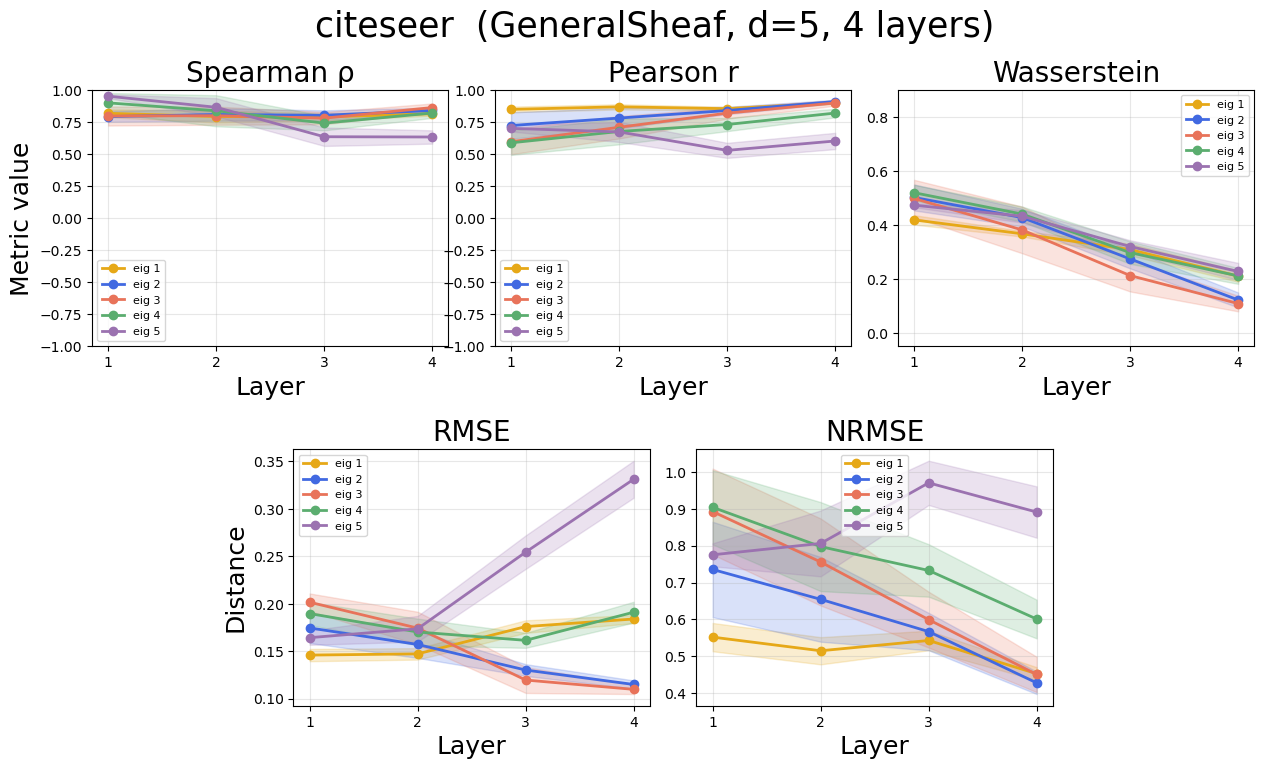

In [10]:
fig = plt.figure(figsize=(15, 8))
gs  = fig.add_gridspec(2, 6, hspace=0.4, wspace=0.3)

ax_sp   = fig.add_subplot(gs[0, 0:2])
ax_pe   = fig.add_subplot(gs[0, 2:4])
ax_wa   = fig.add_subplot(gs[0, 4:6])
ax_rmse = fig.add_subplot(gs[1, 1:3])
ax_nrm  = fig.add_subplot(gs[1, 3:5])

all_metrics = [
    (ax_sp,   "Spearman ρ",  spearman_mean,    spearman_std,    (-1, 1)),
    (ax_pe,   "Pearson r",   pearson_mean,     pearson_std,     (-1, 1)),
    (ax_wa,   "Wasserstein", wasserstein_mean, wasserstein_std, (-0.05, 0.9)),
    (ax_rmse, "RMSE",        rmse_mean,        rmse_std,        None),
    (ax_nrm,  "NRMSE",       nrmse_mean,       nrmse_std,       None),
]

for ax, title, mu_mat, sig_mat, ylim in all_metrics:
    for k in range(d):
        mu  = mu_mat[:, k]
        sig = sig_mat[:, k]
        ax.plot(layer_ticks, mu, marker='o', color=colors[k], label=f"eig {k+1}", lw=2)
        ax.fill_between(layer_ticks, mu - sig, mu + sig, alpha=0.2, color=colors[k])
    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Layer", fontsize=18)
    ax.set_xticks(layer_ticks)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    if ylim is not None:
        ax.set_ylim(ylim)

ax_sp.set_ylabel("Metric value", fontsize=18)
ax_rmse.set_ylabel("Distance", fontsize=18)

fig.suptitle(f"{dataset}  ({model}, d={d}, {layers} layers)", fontsize=25)
#plt.savefig(f"metric_images/{dataset}_{model}_d{d}_{layers}L_Norm_{Norm}_all_metrics.pdf", bbox_inches="tight")
plt.show()